In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
loans = pd.read_csv("loan_data.csv")
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [9]:
#Cleaning Data

df = loans
df["purpose"].count()
df = pd.get_dummies(df, columns=["purpose"], drop_first=True)
df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


In [10]:
#PR Modelling

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['not.fully.paid'])
y = df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

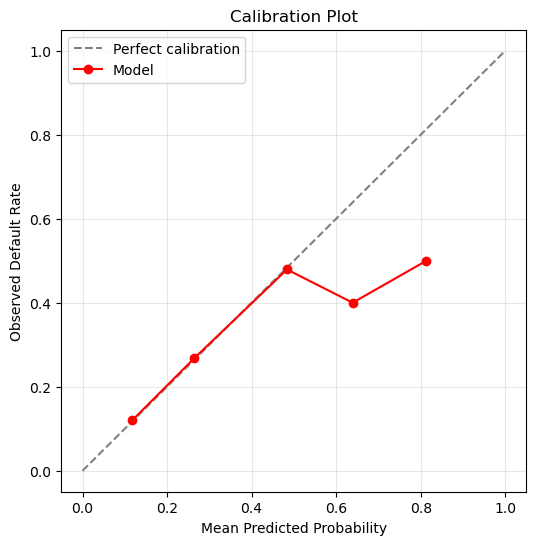

In [11]:
# Visualisation of PR curve

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=5)

plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label='Model', color="red")
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Rate')
plt.title('Calibration Plot')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
from scipy.stats import ks_2samp

# split predicted probabilities by actual outcome
defaulters_scores = y_pred_proba[y_test == 1]
non_defaulters_scores = y_pred_proba[y_test == 0]

ks_stat, p_value = ks_2samp(defaulters_scores, non_defaulters_scores)
print(f"KS Statistic: {ks_stat:.3f}")
print(f"p-value: {p_value:.3g}")

KS Statistic: 0.250
p-value: 1.28e-14


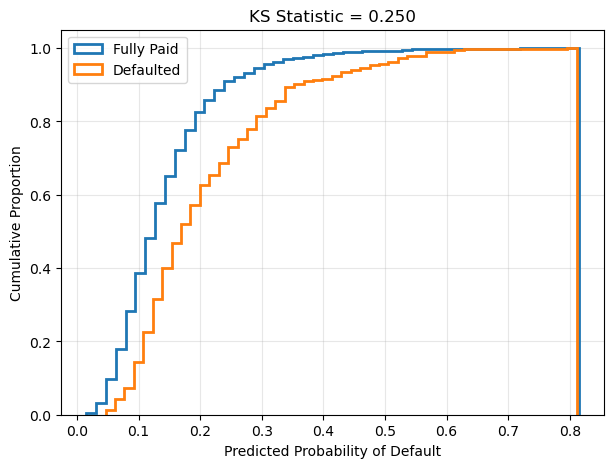

In [14]:
plt.figure(figsize=(7,5))
plt.hist(non_defaulters_scores, bins=50, density=True, cumulative=True,
         histtype='step', label='Fully Paid', linewidth=2)
plt.hist(defaulters_scores, bins=50, density=True, cumulative=True,
         histtype='step', label='Defaulted', linewidth=2)
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Cumulative Proportion')
plt.title(f'KS Statistic = {ks_stat:.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()